## Focus on 'congenital heart disease' network
* CHD genes are defined from this website: https://chdgene.victorchang.edu.au/
* There are 142 genes 

In [1]:
!date +%F

2026-05-21


In [2]:
#!/usr/bin/env python3
import os
import re
import sys
print(sys.executable)
print(sys.path)
print(sys.version)
import pickle

import random
from itertools import combinations
import matplotlib
import glob
import math
%matplotlib inline
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm

import networkx as nx
import gseapy as gp
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'pdf.fonttype':42}) 

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import scipy.sparse as sp_sparse

from tqdm import tqdm
from joblib import Parallel, delayed

print('numpy', np.__version__)
print('pandas', pd.__version__)
print('scipy', scipy.__version__)
print('matplotlib', matplotlib.__version__)

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/bin/python
['/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python312.zip', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/lib-dynload', '', '/home2/s223695/.local/lib/python3.12/site-packages', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages']
3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]


numpy 1.26.4
pandas 2.2.1
scipy 1.15.3
matplotlib 3.8.3


### Load Graph

In [3]:
with open("../Data/GRN_base.pickle","rb") as f:
    G = pickle.load(f)

In [4]:
# --- Size Metrics (User's provided part) ---
TF_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "TF"]
gene_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "gene"]

num_tfs = len(TF_nodes)
num_tgs = len(gene_nodes)
num_interactions = G.number_of_edges()

# --- Topological Measures (Calculation) ---

# Average In-degree: Mean number of incoming edges per target gene
avg_in_degree = num_interactions / num_tgs if num_tgs > 0 else 0

# Average Out-degree: Mean number of outgoing edges per transcription factor
avg_out_degree = num_interactions / num_tfs if num_tfs > 0 else 0

# Clustering Coefficient: Degree to which nodes tend to cluster together
avg_clustering = nx.average_clustering(G)

# Path Length: Average shortest path between all pairs of nodes
# Note: Bio-networks are often disconnected; we calculate for the largest component
if nx.is_weakly_connected(G):
    # Convert to undirected for standard average path length
    avg_path_length = nx.average_shortest_path_length(G.to_undirected())
else:
    # Identify the largest weakly connected component (LWCC)
    lwcc = max(nx.weakly_connected_components(G), key=len)
    subgraph = G.subgraph(lwcc).to_undirected()
    avg_path_length = nx.average_shortest_path_length(subgraph)

# --- Display Results ---
print(f"{'Metric':<30} | {'Value'}")
print("-" * 45)
print(f"No. of transcription factors   | {num_tfs}")
print(f"No. of target genes           | {num_tgs}")
print(f"No. of regulatory interactions | {num_interactions}")
print("-" * 45)
print(f"In-degree <k_in>              | {avg_in_degree:.2f}")
print(f"Out-degree <k_out>            | {avg_out_degree:.2f}")
print(f"Path length <L>               | {avg_path_length:.2f}")
print(f"Clustering coefficient <C>    | {avg_clustering:.3f}")

Metric                         | Value
---------------------------------------------
No. of transcription factors   | 1316
No. of target genes           | 7122
No. of regulatory interactions | 25621
---------------------------------------------
In-degree <k_in>              | 3.60
Out-degree <k_out>            | 19.47
Path length <L>               | 3.94
Clustering coefficient <C>    | 0.015


### Network topology analysis

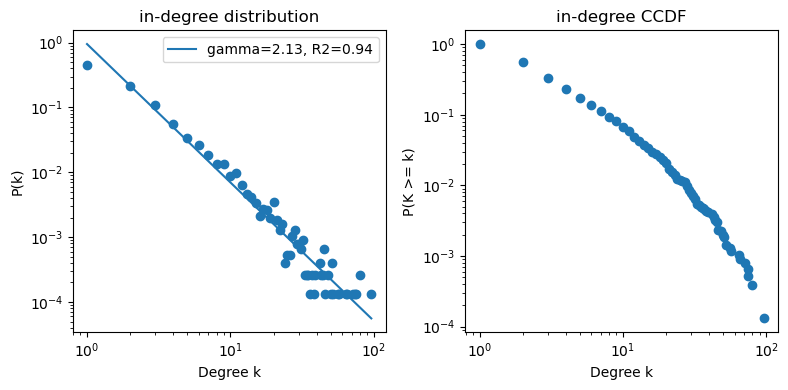

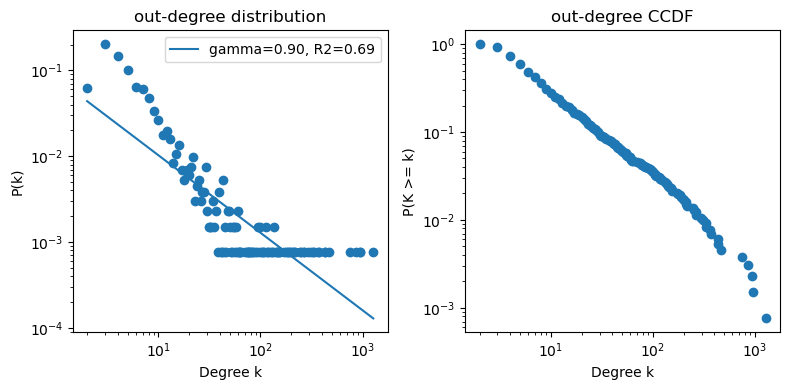

  degree_type  n_nonzero_nodes  max_degree  mean_degree  median_degree  \
0          in             7641          96     3.353095            2.0   
1         out             1316        1274    19.468845            5.0   

   gamma_pdf_approx  loglog_r2  xmin  
0          2.134271   0.943759     1  
1          0.902498   0.691562     1  

Top in-degree hubs:
    node  in_degree
0  TNNC1         96
1   FBN2         80
2   MYL3         80
3  ALPK2         75
4  LAMA4         74
5   MYH7         71
6  KCNQ5         65
7    CKM         64
8   LDB3         57
9   NPPA         56

Top out-degree hubs:
     node  out_degree
0    ISL1        1274
1  TADA2B         950
2   SOX11         941
3   RCOR2         863
4   TBX20         753
5   HAND1         468
6    SOX4         433
7   HIF1A         430
8  NKX2-5         371
9   PITX2         362


In [6]:
def get_degree_array(G, degree_type):
    # Extract in-degree or out-degree values from a directed graph.
    if not G.is_directed():
        raise ValueError("G must be a directed graph for in-degree and out-degree analysis.")

    if degree_type == "in":
        degrees = np.array([d for _, d in G.in_degree()], dtype=int)
    elif degree_type == "out":
        degrees = np.array([d for _, d in G.out_degree()], dtype=int)
    else:
        raise ValueError("degree_type must be 'in' or 'out'.")

    # Zero-degree nodes cannot be plotted on a log scale.
    return degrees[degrees > 0]


def empirical_pdf(degrees):
    # Compute empirical probability mass function P(k).
    k, counts = np.unique(degrees, return_counts=True)
    pk = counts / counts.sum()
    return k, pk, counts


def empirical_ccdf(degrees):
    # Compute empirical complementary cumulative distribution function P(K >= k).
    k, counts = np.unique(degrees, return_counts=True)
    survival_counts = np.cumsum(counts[::-1])[::-1]
    ccdf = survival_counts / survival_counts[0]
    return k, ccdf


def fit_power_law_pdf(k, pk, xmin=1):
    # Fit log10 P(k) = a + b log10 k for k >= xmin.
    # This is a visual approximation, not a rigorous statistical test.
    mask = (k >= xmin) & (pk > 0)

    if mask.sum() < 2:
        return None

    x = np.log10(k[mask])
    y = np.log10(pk[mask])

    slope, intercept = np.polyfit(x, y, 1)
    y_hat = intercept + slope * x

    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    gamma = -slope

    return {
        "slope": slope,
        "intercept": intercept,
        "gamma": gamma,
        "r2": r2,
        "xmin": xmin,
    }


def plot_degree_distribution(G, degree_type, output_name=None,xmin=1):
    # Plot degree distribution and CCDF on log-log axes.
    degrees = get_degree_array(G, degree_type)

    k_pdf, pk, counts = empirical_pdf(degrees)
    k_ccdf, ccdf = empirical_ccdf(degrees)

    fit = fit_power_law_pdf(k_pdf, pk, xmin=xmin)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].scatter(k_pdf, pk)
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Degree k")
    axes[0].set_ylabel("P(k)")
    axes[0].set_title(f"{degree_type}-degree distribution")

    if fit is not None:
        fit_k = k_pdf[k_pdf >= xmin]
        fit_pk = 10 ** (fit["intercept"] + fit["slope"] * np.log10(fit_k))
        axes[0].plot(
            fit_k,
            fit_pk,
            label=f"gamma={fit['gamma']:.2f}, R2={fit['r2']:.2f}"
        )
        axes[0].legend()

    axes[1].scatter(k_ccdf, ccdf)
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Degree k")
    axes[1].set_ylabel("P(K >= k)")
    axes[1].set_title(f"{degree_type}-degree CCDF")

    plt.tight_layout()
    if output_name!=None:
        plt.savefig(output_name)
    plt.show()

    summary = {
        "degree_type": degree_type,
        "n_nonzero_nodes": len(degrees),
        "max_degree": int(degrees.max()) if len(degrees) > 0 else 0,
        "mean_degree": float(degrees.mean()) if len(degrees) > 0 else np.nan,
        "median_degree": float(np.median(degrees)) if len(degrees) > 0 else np.nan,
    }

    if fit is not None:
        summary.update({
            "gamma_pdf_approx": fit["gamma"],
            "loglog_r2": fit["r2"],
            "xmin": fit["xmin"],
        })

    return summary


def top_hubs(G, degree_type, n=10):
    # Return the top hub nodes by in-degree or out-degree.
    if degree_type == "in":
        degree_view = G.in_degree()
        column_name = "in_degree"
    elif degree_type == "out":
        degree_view = G.out_degree()
        column_name = "out_degree"
    else:
        raise ValueError("degree_type must be 'in' or 'out'.")

    hubs = sorted(degree_view, key=lambda x: x[1], reverse=True)[:n]
    return pd.DataFrame(hubs, columns=["node", column_name])


# Choose xmin depending on where the tail seems to start.
# You may need to change these values after seeing the plots.
xmin_in = 1
xmin_out = 1

in_summary = plot_degree_distribution(G, "in", output_name="../Plot/Degree_stat_in.pdf",xmin=xmin_in)
out_summary = plot_degree_distribution(G, "out", output_name="../Plot/Degree_stat_out.pdf", xmin=xmin_out)

summary_df = pd.DataFrame([in_summary, out_summary])
print(summary_df)

print("\nTop in-degree hubs:")
print(top_hubs(G, "in", n=10))

print("\nTop out-degree hubs:")
print(top_hubs(G, "out", n=10))

### Analyze directed property on TF-TF network

In [7]:
def extract_TF_TF_graph(G, direct_graph=False):
    # Create a copy to avoid modifying the original graph
    G_target = G.copy()

    # Filter edges if direct_graph is True
    if direct_graph:
        # Identify edges where 'is_motif' is NOT True (either False or missing)
        edges_to_remove = [(u, v) for u, v, data in G_target.edges(data=True) if data.get("is_motif") is not True]
        # Remove these edges from our working graph
        G_target.remove_edges_from(edges_to_remove)

    # Extract nodes where type is "TF"
    TF_node_list = [node for node, data in G_target.nodes(data=True) if data.get("type") == "TF"]
    TF_TF_network = G_target.subgraph(TF_node_list).copy()

    # Safety check: Handle the case where the filtered network has no nodes
    if len(TF_TF_network) == 0:
        return TF_TF_network

    # Find weakly connected components
    components = list(nx.weakly_connected_components(TF_TF_network))
    
    # Get the largest component
    largest_component = max(components, key=len)
    
    # Create the final subgraph from the filtered network (TF_TF_network)
    TF_TF_sg = TF_TF_network.subgraph(largest_component).copy()
    
    return TF_TF_sg

In [8]:
TF_TF_rand_network = extract_TF_TF_graph(G, direct_graph=True)
print("Node:",len(TF_TF_rand_network.nodes))
print("Edge:",len(TF_TF_rand_network.edges))

Node: 327
Edge: 593


### TF-TF network motif analysis

In [9]:
def generate_degree_preserving_random_network(G, num_swaps_multiplier=10, random_state=None):
    """
    Generate a randomized network while strictly preserving the in-degree 
    and out-degree of every single node.
    If the maximum number of swap attempts is exceeded, it gracefully catches 
    the error and returns the graph at its current randomized state.
    """
    # Provide a default random state if none is supplied
    if random_state is None:
        random_state = np.random.RandomState(42)

    G_rand = G.copy()
    num_edges = G_rand.number_of_edges()
    
    # Number of swaps should be significantly higher than the number of edges
    # to ensure the network is well-randomized.
    swaps = num_edges * num_swaps_multiplier
    max_attempts = swaps * 10
    
    try:
        # Perform double-edge swaps to randomize connections.
        # This function modifies G_rand in-place.
        nx.directed_edge_swap(G_rand, nswap=swaps, max_tries=max_attempts, seed=random_state)
        
    except nx.NetworkXAlgorithmError:
        # If it reaches max_tries and cannot find valid edges to swap, 
        # it throws an error. We catch it and pass.
        # G_rand currently holds all successful swaps made up to this point.
        pass
        
    return G_rand

In [10]:
census = nx.triadic_census(TF_TF_rand_network)

In [11]:
census

{'003': 5588984,
 '012': 177979,
 '102': 291,
 '021D': 4448,
 '021U': 1295,
 '021C': 1156,
 '111D': 11,
 '111U': 23,
 '030T': 85,
 '030C': 3,
 '201': 0,
 '120D': 0,
 '120U': 0,
 '120C': 0,
 '210': 0,
 '300': 0}

In [12]:
len(census.keys())

16

In [13]:
def worker(base_graph, multiplier, seed):
    # Initialize an independent random state using the unique seed provided
    rs = np.random.RandomState(seed)
    rand_net = generate_degree_preserving_random_network(base_graph, multiplier, random_state=rs)
    return nx.triadic_census(rand_net)

num_random_graph = 10000

# 1. Create a master random state for overall script reproducibility
master_rs = np.random.RandomState(42)

# 2. Generate 2000 unique seeds using the master random state
# This ensures that the same 2000 different seeds are generated every time you run the script.
# High upper bound ensures no seed collisions.
worker_seeds = master_rs.randint(0, 2**32 - 1, size=num_random_graph)

# 3. Execute in parallel, passing one unique seed to each worker
census_random_list = Parallel(n_jobs=-1)(
    delayed(worker)(TF_TF_rand_network, 10, worker_seeds[i]) 
    for i in tqdm(range(num_random_graph))
)

  0%|          | 0/10000 [00:00<?, ?it/s]

  1%|          | 64/10000 [00:00<02:01, 81.56it/s]

  1%|▏         | 128/10000 [00:01<02:32, 64.70it/s]

  2%|▏         | 192/10000 [00:02<02:10, 75.32it/s]

  3%|▎         | 256/10000 [00:03<02:01, 80.36it/s]

...

 98%|█████████▊| 9792/10000 [01:50<00:02, 89.08it/s]

 99%|█████████▊| 9856/10000 [01:51<00:01, 88.80it/s]

 99%|█████████▉| 9920/10000 [01:52<00:00, 88.26it/s]

100%|█████████▉| 9984/10000 [01:53<00:00, 88.16it/s]

100%|██████████| 10000/10000 [01:53<00:00, 88.35it/s]

In [14]:
stat_df = pd.DataFrame(census_random_list)

In [15]:
stat_df

,003,012,102,021D,021U,021C,111D,111U,030T,030C,201,120D,120U,120C,210,300
0,5590065,176011,1393,4294,1254,958,50,165,70,0,1,1,11,1,1,0
1,5589279,177417,597,4429,1271,1132,23,30,97,0,0,0,0,0,0,0
2,5589193,177669,545,4350,1249,1045,19,80,116,3,0,1,4,1,0,0
3,5588955,178065,298,4424,1256,1128,14,12,119,3,0,1,0,0,0,0
4,5589549,176926,888,4401,1237,1079,40,40,110,1,3,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,5589261,177466,586,4431,1254,1119,33,26,94,0,0,5,0,0,0,0
9996,5588958,178057,282,4421,1275,1134,12,31,104,1,0,0,0,0,0,0
9997,5589815,176447,1155,4350,1242,1022,43,94,98,1,0,0,6,2,0,0
9998,5590111,175879,1430,4333,1261,996,43,138,72,1,3,4,2,2,0,0


In [16]:
def calculate_motif_statistics(census_real, stat_df):
    """
    Calculate statistical significance (P-value and Z-score) for each network motif.
    
    census_real: Dictionary containing the triadic census of the original graph.
    stat_df: DataFrame containing the triadic census of the randomized graphs.
    """
    results = []
    num_random_graphs = len(stat_df)
    
    for motif, real_count in census_real.items():
        # Ensure the motif exists in the randomized DataFrame
        if motif not in stat_df.columns:
            continue
            
        # Extract the random distribution for this specific motif
        rand_distribution = stat_df[motif]
        
        # Calculate the mean and standard deviation of the random distribution
        rand_mean = rand_distribution.mean()
        rand_std = rand_distribution.std()
        
        # Calculate Z-score: (Real Count - Random Mean) / Random Std
        # Handle division by zero if all random graphs have the exact same count
        if rand_std > 0:
            z_score = (real_count - rand_mean) / rand_std
        else:
            z_score = 0.0
            
        # Calculate P-value for over-representation (motif is found more often than random)
        # It counts how many random graphs have a count greater than or equal to the real count
        p_value_over = (rand_distribution >= real_count).sum() / num_random_graphs
        
        # Calculate P-value for under-representation (anti-motifs)
        p_value_under = (rand_distribution <= real_count).sum() / num_random_graphs
        
        results.append({
            'Motif': motif,
            'Real_Count': real_count,
            'Random_Mean': rand_mean,
            'Random_Std': rand_std,
            'Z_Score': z_score,
            'P_Value_Over': p_value_over,
            'P_Value_Under': p_value_under
        })
        
    # Convert the results to a DataFrame for easy viewing
    result_df = pd.DataFrame(results)
    
    # Sort by Z-score descending to highlight the most significantly over-represented motifs
    result_df = result_df.sort_values(by='Z_Score', ascending=False).reset_index(drop=True)
    
    return result_df

# Execute the function using your existing variables
# 'census' is from cell [24], 'stat_df' is from cell [30]
motif_stats_df = calculate_motif_statistics(census, stat_df)

# Display the results
display(motif_stats_df)

,Motif,Real_Count,Random_Mean,Random_Std,Z_Score,P_Value_Over,P_Value_Under
0,021U,1295,1.263119e+03,19.328217,1.649469,0.0391,0.9660
1,021D,4448,4.385166e+03,47.150814,1.332622,0.0670,0.9373
2,021C,1156,1.078290e+03,61.840110,1.256625,0.0998,0.9044
3,030C,3,1.706100e+00,1.454763,0.889423,0.2483,0.8854
4,012,177979,1.774178e+05,720.649024,0.778744,0.2987,0.7020
5,300,0,2.700000e-03,0.051894,-0.052029,1.0000,0.9973
6,210,0,1.318000e-01,0.398051,-0.331113,1.0000,0.8865
7,201,0,4.508000e-01,0.883209,-0.510412,1.0000,0.7039
8,111D,11,2.328270e+01,15.861795,-0.774358,0.7811,0.2451
9,120C,0,9.685000e-01,1.198604,-0.808023,1.0000,0.4645


In [17]:
motif_stats_df.to_csv("../Data/motif_stats.csv")

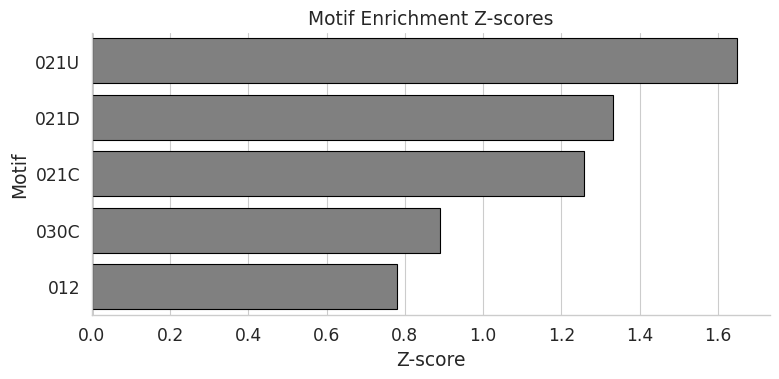

In [19]:
# Sort motifs by Z-score
plot_df = motif_stats_df.sort_values("Z_Score", ascending=False).head(5).copy()

# Set publication-friendly style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)

fig, ax = plt.subplots(figsize=(8, 4))

# Create horizontal bar plot
sns.barplot(
    data=plot_df,
    x="Z_Score",
    y="Motif",
    ax=ax,
    color="gray",
    edgecolor="black"
)

# Add vertical reference line at Z = 0
ax.axvline(0, color="black", linewidth=1)

# Set axis labels
ax.set_xlabel("Z-score")
ax.set_ylabel("Motif")

# Set title
ax.set_title("Motif Enrichment Z-scores")

# Remove top and right spines
sns.despine(ax=ax)

# Improve layout
plt.tight_layout()

# Save figure for publication
plt.savefig("../Plot/motif_z_scores_barplot.pdf", bbox_inches="tight")

plt.show()

### Small-world network

In [20]:
in_degrees = dict(TF_TF_rand_network.in_degree())
out_degrees = dict(TF_TF_rand_network.out_degree())

in_degree_values = list(in_degrees.values())
out_degree_values = list(out_degrees.values())

in_degree_max = max(in_degree_values)
out_degree_max = max(out_degree_values)

In [21]:
in_degree_df = pd.DataFrame(in_degrees.values(),index=in_degrees.keys(),columns=["Count"])
out_degree_df = pd.DataFrame(out_degrees.values(),index=out_degrees.keys(),columns=["Count"])

In [22]:
out_degree_df.sort_values("Count",ascending=False)

,Count
ISL1,62
SOX11,36
RCOR2,26
HAND1,24
TBX20,19
...,...
HEY1,0
SMAD1,0
ID2,0
HOXB6,0


<Axes: ylabel='Count'>

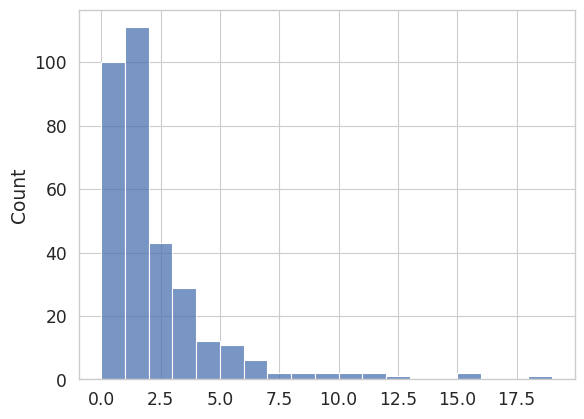

In [23]:
sns.histplot(in_degree_values,bins=range(in_degree_max))

<Axes: ylabel='Count'>

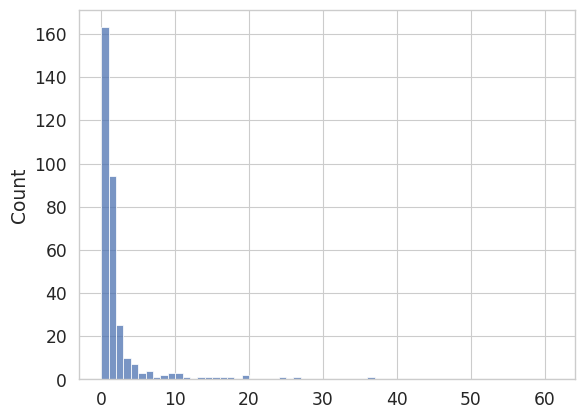

In [24]:
sns.histplot(out_degree_values,bins=range(out_degree_max))